# Этап №4. | AI/ML | Прототип рабочего контура RAG и первая точность retrieval (Hit@k)

**Проект:** интеллектуальный Telegram-бот с RAG по Правилам устройства электроустановок (ПУЭ), 7-е издание.  
**Репозиторий:** `Итоговы_Проект` (ветка дипломной работы).  
**Дата отчёта:** 27.09.2026.

**Расположение файлов этапа 4:** каталог `Этапы/Reports/etap4/` (см. также `Этапы/Reports/README.md`).

| Подкаталог / файл | Назначение |
|-------------------|------------|
| `Readme-4.md`, `Readme-4 (ver. 2).ipynb` | Текст для Word и исполняемый ноутбук |
| `data/stage4_eval_questions.json` | Тестовые вопросы и эталоны Clause |
| `retrieval/` | Hit@k: JSON, история прогонов, PNG-графики |
| `generation/` | Метрики RAG-generation (`eval_rag_generation.py`) |

**Версия 2 (рабочий документ).** Текст разделов 1–8 синхронизирован с `Readme-4.md` (мастер для Word). Ниже — оглавление и исполняемые ячейки.

**Содержание отчёта:**
1. [Тема и описание задачи](#sec-1)
2. [База данных](#sec-2)
3. [Параметризация данных](#sec-3)
4. [Архитектура рабочего контура RAG](#sec-4)
5. [Графическое подтверждение (Hit@k)](#sec-5)
6. [Ноутбук или .py файл (прототип)](#sec-6)
7. [Выводы](#sec-7)
8. [План дальнейшей работы](#sec-8)


**Как пользоваться.** (1) Bootstrap. (2) Docker / Milvus. (3) Раздел 5: **§5.2** прогон → **§5.3** таблица/Plotly (или §5.3 с `force_eval=True`). (4) Раздел 6 — demo Milvus. (5) **§7** — code-ячейка выводов после §5.2. Текст: `Readme-4.md` → `python scripts/sync_readme4_notebook.py`.


In [2]:
from pathlib import Path

for _p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (_p / "scripts" / "notebook_bootstrap.py").is_file():
        break
else:
    raise FileNotFoundError("scripts/notebook_bootstrap.py не найден")

__file__ = str(_p / "scripts" / "notebook_bootstrap.py")
__name__ = "__main__"
exec(compile(Path(__file__).read_text(encoding="utf-8"), __file__, "exec"), globals())

Корень проекта: X:\Учеба_УИИ\Итоговы_Проект


In [4]:
# Docker: Milvus (3 сервиса) + Ollama — нужен запущенный Docker Desktop
#
# Если в выводе: «GPU виден в nvidia-smi, но torch.cuda недоступен»:
#   Ollama на GPU уже ок; эмбеддинги (Hit@k, search_text) — PyTorch в .venv.
#   Установка CUDA-сборки (PowerShell, из корня, venv активен):
#     pip uninstall torch torchvision -y
#     pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
#     python -c "import torch; print('cuda:', torch.cuda.is_available())"
#   RTX 50xx: чаще cu128 (см. start/Readme.md). Без GPU-эмбеддингов — только CPU в конфиге:
#     python scripts/compute_detect.py --apply-config
import subprocess
import sys

_script = ROOT / "scripts" / "start_report_docker.py"
if not _script.is_file():
    raise FileNotFoundError(_script)

_proc = subprocess.run(
    [sys.executable, str(_script)],
    cwd=str(ROOT),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
)
if _proc.stdout:
    print(_proc.stdout, end="")
if _proc.stderr:
    print(_proc.stderr, end="")
if _proc.returncode != 0:
    raise SystemExit(_proc.returncode)

=== Milvus (etcd, minio, standalone) ===
Каталог compose: X:\Учеба_УИИ\Итоговы_Проект\infra\milvus
NAME                IMAGE                                      COMMAND                  SERVICE      CREATED        STATUS                                     PORTS
milvus-etcd         quay.io/coreos/etcd:v3.5.25                "etcd -advertise-cli…"   etcd         3 months ago   Up 1 second (health: starting)             2379-2380/tcp
milvus-minio        minio/minio:RELEASE.2024-12-18T13-15-44Z   "/usr/bin/docker-ent…"   minio        3 months ago   Up 1 second (health: starting)             0.0.0.0:9000-9001->9000-9001/tcp, [::]:9000-9001->9000-9001/tcp
milvus-standalone   milvusdb/milvus:v2.6.11                    "/tini -- milvus run…"   standalone   3 months ago   Up Less than a second (health: starting)   0.0.0.0:9091->9091/tcp, [::]:9091->9091/tcp, 0.0.0.0:19530->19530/tcp, [::]:19530->19530/tcp

=== Ollama ===
Режим Ollama: GPU
LLM (рекомендация): qwen2.5:14b-instruct-q4_K_M — gpu 

<a id="sec-1"></a>
## 1. Тема и описание задачи

### Тема

«Разработка интеллектуального Telegram-бота на основе языковой модели для консультирования по нормативной документации в области электроэнергетики (ПУЭ, ПТЭЭП, ГОСТ)».

### Фокус этапа 4 (MVP по рекомендации куратора)

На четвёртом этапе сужен контур до **ПУЭ**: построен **прототип рабочего контура RAG** (Retrieval-Augmented Generation):

1. **Retrieval** — один семантический проход: вопрос → эмбеддинг → **`search_text`** в Milvus → top-k фрагментов ПУЭ.
2. **Generation** — ответ LLM (Ollama) по найденным фрагментам; модуль **`src/rag/rag_service.py`** (`answer()`).

**Важно:** «первая точность» этапа 4 — это **Hit@k только для retrieval** (один поиск на вопрос), а не «двойной поиск» и не accuracy обучения с нуля.

### Задача этапа в терминах курса

| Формулировка платформы | Интерпретация в проекте |
|------------------------|-------------------------|
| Прототип нейросети (НС) / прототип системы | **Прототип рабочего контура RAG** на предобученных моделях: (1) SentenceTransformer; (2) LLM Ollama. Обучение весов с нуля не выполнялось. |
| Первая точность распознавания | **Hit@k** после **одного** `search_text`: доля запросов, где эталонный **Clause** есть среди top-*k*. Не «двойной поиск», не loss по эпохам. |

### Ожидаемый результат этапа

- Рабочий контур **«вопрос → эмбеддинг → Milvus → top-k → (опционально) LLM»**.
- Набор тестовых вопросов с эталонными пунктами и процедура расчёта Hit@1 / Hit@3 / Hit@5.
- Описание архитектуры полного RAG (retrieval + LLM) для следующей итерации (Telegram-бот, этап 5).

---


<a id="sec-2"></a>
## 2. База данных

### Источник

**Правила устройства электроустановок (ПУЭ), 7-е издание** — главы в формате DOCX, разбитые по файлам (например `1.1.docx` … `7.10.docx`, приложения).

- Исходники: `data/raw/Нормативная база/ПУЭ/DOCX/`
- Публичная копия (этап 2): [GitHub — raw/ПУЭ/DOCX](https://github.com/kirag-ozyaz/Diplom_AI/tree/main/data/raw/Нормативная%20база/ПУЭ/DOCX)

Конфиденциальных данных нет — норматив открыт для цитирования в учебных целях.

### Объём после этапов 2–3

| Слой | Каталог | Содержание |
|------|---------|------------|
| Markdown | `data/extracted/` | ~44 файла `*.md` + каталоги `image_*` |
| Чанки | `data/chunked/` | ~43 файла `*.chunked.jsonl` |
| Векторы | Milvus, коллекция `diplom_multimodal` | Эмбеддинги текстовых чанков (и опционально CLIP для изображений; см. `manual/OpenCLIP_ViT-B-32.md`) |

Пример записи чанка (фрагмент JSONL):

```json
{
  "id": "pue_1.1.1_418533c2",
  "metadata": {
    "Document": "ПРАВИЛА УСТРОЙСТВА ЭЛЕКТРОУСТАНОВОК",
    "Section": "Раздел 1 ОБЩИЕ ПРАВИЛА",
    "Paragraph": "Область применения. Определения",
    "Clause": "1.1.1",
    "source_file": "1.1.md"
  },
  "content": "... текст пункта 1.1.1 ..."
}
```

ПТЭЭП и ГОСТ на этапе 4 **не включались** — только ПУЭ, в соответствии с MVP.

---


In [5]:
chunked_dir = ROOT / "data" / "chunked"
jsonl_files = sorted(chunked_dir.glob("*.chunked.jsonl")) if chunked_dir.is_dir() else []
print(f"Файлов chunked JSONL: {len(jsonl_files)}")
if jsonl_files:
    sample = json.loads(jsonl_files[0].read_text(encoding="utf-8").splitlines()[0])
    print("Ключи записи:", list(sample.keys()))
    print("Пример Clause:", sample.get("metadata", {}).get("Clause"))

Файлов chunked JSONL: 43
Ключи записи: ['id', 'metadata', 'content', 'created_at']
Пример Clause: 


<a id="sec-3"></a>
## 3. Параметризация данных

### 3.1. Сегментация (этап 3, используется в прототипе)

- Парсер `PueMetadataParser` (`src/preprocessing/Create_chunkeds/md_to_chunked_2.py`): раздел, глава, paragraph, **Clause** (номер пункта).
- В текст чанка добавляется контекстный префикс (документ, раздел, пункт) для улучшения качества эмбеддинга.

### 3.2. Векторизация

| Параметр | Значение / источник |
|----------|---------------------|
| Модель текста | Автовыбор по GPU: `config/model_profiles.json` + `model_selector.py` (например `all-MiniLM-L6-v2`, `multilingual-e5-base`, `bge-m3`) |
| Размерность | Из `embedding_config.json` по имени модели |
| Нормализация | `normalize_embeddings=True` |
| Устройство | `device_text`: `cuda` или `cpu` — `config/rag_runtime.json` |

### 3.3. Векторная БД

| Параметр | Значение |
|----------|----------|
| СУБД | Milvus standalone (Docker) |
| Host / port | `localhost:19530` |
| Коллекция | `diplom_multimodal` |
| Индекс | HNSW по полю `text_vector` |
| Метаданные в записи | `text`, `chunk_id`, `source_file`, `chapter`, `has_image`, … |

### 3.4. Параметры поиска (прототип)

| Параметр | Значение |
|----------|----------|
| `query.default_limit` | 5 (`config/rag_runtime.json`) |
| Для оценки Hit@k | **k ∈ {1, 3, 5}**, лимит выдачи ≥ 5 |
| Метрика сходства | Косинусное расстояние / score Milvus (выше — релевантнее) |

### 3.5. LLM (прототип generation)

| Параметр | Значение |
|----------|----------|
| Среда | Ollama в Docker (`infra/docker/Dockerfile.ollama/`) |
| API | `http://localhost:11434` |
| Рекомендуемая модель (6 ГБ VRAM) | `qwen2.5:3b` |
| Роль в RAG | На вход: системный промпт + top-k фрагментов ПУЭ + вопрос пользователя; на выход: краткий ответ с номерами пунктов |

---


In [6]:
from runtime_config import load_runtime_config

cfg = load_runtime_config(ROOT / "config" / "rag_runtime.json")
print("Коллекция:", cfg["vector_db"]["collection_name"])
print("Embedding (config):", cfg["models"]["text_model_name"])
print("device_text:", cfg["models"]["device_text"])
print("Ollama model (config):", cfg["ollama"]["model"])

Коллекция: diplom_multimodal
Embedding (config): intfloat/multilingual-e5-base
device_text: cuda
Ollama model (config): qwen2.5:3b


<a id="sec-4"></a>
## 4. Архитектура рабочего контура (прототип RAG)

### 4.1. Общая схема

```
        Пользовательский вопрос (RU)
                    │
                    ▼
        ┌──────────────────────────┐
        │   SentenceTransformer    │
        │  НС #1 · text → vector   │
        └────────────┬─────────────┘
                     ▼
        ┌──────────────────────────┐
        │      Milvus (HNSW)       │
        │      search_text()       │
        │   top-k чанков ПУЭ       │
        └────────────┬─────────────┘
                     ▼
        ┌──────────────────────────┐
        │   Промпт + контекст      │
        └────────────┬─────────────┘
                     ▼
        ┌──────────────────────────┐
        │       Ollama LLM         │
        │  НС #2 · генерация       │
        └────────────┬─────────────┘
                     ▼
        Ответ с ссылками на пункты ПУЭ
```

### 4.2. Реализованные модули (код)

| Компонент | Файл | Статус этапа 4 |
|-----------|------|----------------|
| Загрузка в Milvus | `src/preprocessing/Create_embeddings/load_data.py` | да |
| Класс RAG / поиск | `src/preprocessing/Create_embeddings/multimodal_rag.py` | да |
| Интерактивный поиск | `src/preprocessing/Create_embeddings/query.py` | да |
| Быстрый тест запроса | `src/preprocessing/Create_embeddings/query_test.py` | да |
| Runtime-конфиг | `config/rag_runtime.json` | да |
| Оценка Hit@k | `scripts/stage4_eval/eval_retrieval_hitk.py` | да (прогон при запущенном Milvus) |
| RAG + Ollama | `src/rag/rag_service.py`, `ollama_client.py` | да |

### 4.3. Логика «распознавания» пункта ПУЭ

Эталон для запроса — строка **Clause** (например `1.7.103`).  
Успех Hit@k: в первых *k* результатах **одного** вызова `search_text` в поле `text` встречается номер пункта (регулярные выражения в скрипте оценки).

Это соответствует задаче «найти правильный фрагмент норматива по смыслу вопроса». Теоретическое обоснование метрики — в п. 4.4.

### 4.4. Теория метрики Hit@k

**Hit@k** (также *Hit Rate@k*, *Hits@K*) — это не параметр нейросети, а стандартная метрика **ранжированного поиска** (information retrieval): доля запросов, для которых хотя бы один релевантный документ попал в первые *k* позиций выдачи.

На этапе 4 она используется как «первая точность распознавания»: модели эмбеддингов и LLM **не дообучались** на ПУЭ, поэтому график loss/accuracy по эпохам неприменим. Для RAG важнее другое: попал ли нужный пункт ПУЭ в top-*k* контекст, который затем передаётся в LLM.

#### Определение и формула

Для одного запроса *q*:

- **hit@k(q) = 1**, если релевантный документ есть среди первых *k* результатов;
- **hit@k(q) = 0** иначе.

По набору из *N* запросов:

**Hit@k = (1 / N) · Σ hit@k(q)**

В прототипе: *N* = 73 (`stage4_eval_questions.json`; число строк в JSON, обновляется после eval), релевантность — один эталонный **Clause**, *k* ∈ {1, 3, 5}. Всегда выполняется **Hit@1 ≤ Hit@3 ≤ Hit@5**.

| Метрика | Смысл в проекте |
|---------|-----------------|
| Hit@1 | Эталонный пункт оказался **первым** |
| Hit@3 | Эталонный пункт есть в **тройке** |
| Hit@5 | Эталонный пункт есть в **пятёрке** (лимит выдачи RAG) |

#### Связь с классическими метриками IR

В учебнике Manning, Raghavan, Schütze (*Introduction to Information Retrieval*, 2008, **гл. 8**) для ранжированной выдачи вводятся **Precision@k** и **Recall@k**: оценка идёт не по всему корпусу, а по первым *k* документам.

Если у запроса **ровно один** релевантный документ (как здесь: один `Clause`), то Recall@k равна 1 при попадании этого документа в top-*k* и 0 иначе. Среднее по запросам **совпадает с Hit@k**. Поэтому в данной постановке Hit@k ≡ Recall@k.

Precision@k при одном эталоне равна 1/*k* при попадании и 0 при промахе: она штрафует сам размер выдачи и хуже читается как «доля успешных вопросов». Для RAG достаточно бинарного вопроса: *дошёл ли нужный пункт до генератора*.

В нейросетевом поиске для QA ту же величину называют **top-k retrieval accuracy** — доля вопросов, у которых ответ содержится среди top-*k* найденных пассажей (Karpukhin et al., *Dense Passage Retrieval for Open-Domain Question Answering*, EMNLP 2020). Это ближайший аналог для контура RAG.

Само название Hits@K / Hit Ratio@K широко используется в ранжировании, рекомендательных системах и оценке эмбеддингов графов знаний; математика та же, но для диплома опорными являются **IR (Recall@k)** и **DPR (top-k accuracy)**.

#### Как считается в коде

Скрипт `scripts/stage4_eval/eval_retrieval_hitk.py`: один вызов `search_text` на вопрос; успех, если в поле `text` одного из первых *k* чанков встречается номер пункта (`1.1.4`, `п. 1.1.4`, `Пункт 1.1.4`). Оценивается **только retrieval**, не качество ответа LLM: если эталон не попал в контекст, генерация не может опереться на нужную норму.

Источники: список в **Приложениях**.

---


<a id="sec-5"></a>
## 5. Графическое подтверждение (метрики прототипа)

Классический график **loss / accuracy по эпохам обучения** для данного проекта **не применим**: модели эмбеддингов и LLM не дообучались на ПУЭ.

Вместо этого используются:

1. **Столбчатая диаграмма Hit@1, Hit@3, Hit@5** (%) — в ноутбуке интерактивно (Plotly); для Word и `Readme-4.md` — файлы PNG ниже.
2. **Пример выдачи** `query_test.py` — скрин или текст: запрос, score, фрагмент текста, глава.

**§5.2 — прогон**, **§5.3 — результаты:** метрики только из `eval_retrieval_hitk.py` (JSON на диске). **Ollama / LLM к Hit@k не относятся**; §5.3 в ноутбуке — форматирование JSON, не «ответ нейросети».

### 5.1. Как получить график

1. Запустить Docker-сервисы (Milvus + Ollama для этапа 4):

```powershell
cd X:\Учеба_УИИ\Итоговы_Проект
python scripts/start_report_docker.py
```

Только Milvus (Hit@k / поиск без LLM): `python scripts/start_milvus.py` или `python scripts/start_report_docker.py --skip-ollama`.

В ноутбуке: вторая code-ячейка после bootstrap вызывает `start_report_docker.py` (в ячейке — комментарий с установкой PyTorch CUDA при предупреждении про `torch.cuda`).

**Если в выводе:** «GPU виден в nvidia-smi, но torch.cuda недоступен» — LLM (Ollama) может быть на GPU; **эмбеддинги** (Hit@k, `search_text`) идут через PyTorch в `.venv`. Установка (PowerShell, venv активен):

```powershell
pip uninstall torch torchvision -y
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
python -c "import torch; print('cuda:', torch.cuda.is_available())"
```

Для RTX 5060 Ti и новее — **cu128** (`start/Readme.md`). Оставить эмбеддинги на CPU: `python scripts/compute_detect.py --apply-config`.

Проверка Milvus:

```powershell
cd infra\milvus
docker compose ps
```
2. Убедиться, что коллекция загружена: `python src/preprocessing/Create_embeddings/load_data.py` (при необходимости)


<a id="sec-5-2"></a>
### 5.2. Прогон оценки Hit@k

Полная процедура (Docker, Hit@k, generation): **`scripts/stage4_eval/README.md`**.

В ноутбуке: **code-ячейка §5.2** (после этого заголовка) — полный прогон по Milvus без терминала.

Альтернатива из PowerShell (тот же код):

```powershell
cd X:\Учеба_УИИ\Итоговы_Проект
.\.venv\Scripts\Activate.ps1
python scripts/stage4_eval/eval_retrieval_hitk.py
```

Сохраняются в `etap4/retrieval/`: `stage4_hitk_results.json`, `stage4_hitk_chart.png`, `stage4_hitk_report.png`; обновляется блок §5.3 в этом файле.


In [7]:
# §5.2: прогон Hit@k (Milvus) → JSON и PNG для Word
import importlib.util
import sys

_scripts = ROOT / "scripts"
if str(_scripts) not in sys.path:
    sys.path.insert(0, str(_scripts))

_spec = importlib.util.spec_from_file_location(
    "stage4_hitk_notebook", _scripts / "stage4_eval" / "stage4_hitk_notebook.py"
)
_nb = importlib.util.module_from_spec(_spec)
sys.modules["stage4_hitk_notebook"] = _nb
assert _spec.loader is not None
_spec.loader.exec_module(_nb)

print("Старт прогона Hit@k (25 вопросов, только retrieval)...")
results = _nb.run_eval(REPORTS, ROOT, refresh_readme=True)
globals()["STAGE4_HITK_RESULTS"] = results
m = results["metrics_percent"]
print(
    f"Готово: {results['evaluated_at']} | "
    f"Hit@1 {m['hit@1']}% Hit@3 {m['hit@3']}% Hit@5 {m['hit@5']}%"
)
print("Запустите ячейку §5.3 ниже для таблицы и Plotly (или Run All от §5.2).")


Старт прогона Hit@k (25 вопросов, только retrieval)...
✅ Подключение к векторной БД: localhost:19530
⚠️ В конфиге device_text/device_clip='cuda' для текстовой модели, но PyTorch установлен без CUDA — используется cpu.
   Для ускорения на GPU (RTX): pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124
📥 Загрузка текстовой модели: intfloat/multilingual-e5-base
   ⬇️ Проверка/скачивание файлов модели (HuggingFace cache)...


Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

   ✅ Файлы текстовой модели готовы (в кэше)


X:\Учеба_УИИ\Итоговы_Проект\src\preprocessing\Create_embeddings\multimodal_rag.py:283: UserWarning: При загрузке multilingual-e5 в логе HuggingFace иногда «embeddings.position_ids | UNEXPECTED» — это нормально, на поиск и Hit@k не влияет.
  self._load_text_model(text_model_name, device_text)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Текстовая модель готова
ℹ️ CLIP не загружается (режим только текстового поиска)
✅ MultimodalRAG инициализирован
   📝 Текст: intfloat/multilingual-e5-base на cpu
✅ Коллекция загружена в память
Вопросов: 25, модель: intfloat/multilingual-e5-base
  Hit@1: 10/25 (40.0%)
  Hit@3: 11/25 (44.0%)
  Hit@5: 12/25 (48.0%)
Результаты: X:\Учеба_УИИ\Итоговы_Проект\Этапы\Reports\stage4_hitk_results.json
PNG 1 (Word/md): X:\Учеба_УИИ\Итоговы_Проект\Этапы\Reports\stage4_hitk_chart.png
PNG 2 (Word/md): X:\Учеба_УИИ\Итоговы_Проект\Этапы\Reports\stage4_hitk_report.png
Readme-4.md: обновлены §5.3, §6.1, §7, N=25
Updated: Этапы\Reports\Readme-4 (ver. 2).ipynb
🔌 Соединение с векторной БД закрыто
Готово: 06.10.2026 00:39 | Hit@1 40.0% Hit@3 44.0% Hit@5 48.0%
Запустите ячейку §5.3 ниже для таблицы и Plotly (или Run All от §5.2).


<a id="sec-5-3"></a>
### 5.3. Результаты прогона

В ноутбуке: **code-ячейка §5.3** — таблица и Plotly по актуальному `stage4_hitk_results.json` (после §5.2 в той же сессии или `force_eval=True` в ячейке).


§5.3 — данные прогона: 06.10.2026 00:39


### 5.3. Результаты прогона

**Источник:** только последний прогон **`scripts/stage4_eval/eval_retrieval_hitk.py`** (Milvus + SentenceTransformer, поле `details` в JSON). **Ollama / LLM не используются.** Текст §5.3 — автоматическое форматирование чисел из JSON, не генерация ответа моделью.

Коллекция: `diplom_multimodal`, **2912** записей в Milvus. Модель при оценке: `intfloat/multilingual-e5-base`.
Последний прогон: **06.10.2026 00:39** (`python scripts/stage4_eval/eval_retrieval_hitk.py`).
Inference эмбеддингов при прогоне eval: **cpu**.
Число запросов *N* — из `stage4_eval_questions.json`; метрики — из `Этапы/Reports/stage4_hitk_results.json`.
Полный JSON: `Этапы/Reports/stage4_hitk_results.json`.

| Метрика | Значение | Комментарий |
|---------|----------|-------------|
| Hit@1 | **10 / 25 (40,0 %)** | Эталонный пункт на 1-м месте |
| Hit@3 | **11 / 25 (44,0 %)** | Эталонный пункт в top-3 |
| Hit@5 | **12 / 25 (48,0 %)** | Эталонный пункт в top-5 |
| Число запросов | **25** | `stage4_eval_questions.json` |
| Сводка JSON | Hit@1 40.0 %, Hit@3 44.0 %, Hit@5 48.0 % | `metrics_percent` в JSON |

Примеры успешных Hit@5: id 3, id 8, id 16, id 17, id 18, id 19, id 20, id 21, id 22, id 23, id 24, id 25.
Промахи Hit@5: **13** вопросов (id: 1, 2, 4, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15).
Средний cosine top-1: при Hit@5 **0.859**, при промахе Hit@5 **0.858**.


**История прогонов** (каждый вызов `eval_retrieval_hitk.py`, файл `Этапы/Reports/stage4_hitk_runs.jsonl`):

| Прогон (eval) | N | Hit@1 | Hit@3 | Hit@5 | Модель |
|---|---:|---:|---:|---:|---|
| 06.10.2026 00:39 | 25 | 40.0 % | 44.0 % | 48.0 % | `intfloat/multilingual-e5-base` |
| 29.09.2026 02:49 | 25 | 40.0 % | 44.0 % | 48.0 % | `intfloat/multilingual-e5-base` |
| 29.09.2026 02:43 | 25 | 40.0 % | 44.0 % | 48.0 % | `intfloat/multilingual-e5-base` |
| 29.09.2026 02:36 | 25 | 40.0 % | 44.0 % | 48.0 % | `intfloat/multilingual-e5-base` |
| 29.09.2026 02:27 | 25 | 40.0 % | 44.0 % | 48.0 % | `intfloat/multilingual-e5-base` |
| 29.09.2026 02:22 | 25 | 40.0 % | 44.0 % | 48.0 % | `intfloat/multilingual-e5-base` |
| 29.09.2026 00:36 | 25 | 40.0 % | 44.0 % | 48.0 % | `intfloat/multilingual-e5-base` |

После изменения вопросов в JSON снова выполните eval — блок обновится автоматически.

PNG для Word/md: X:\Учеба_УИИ\Итоговы_Проект\Этапы\Reports\stage4_hitk_chart.png
PNG для Word/md: X:\Учеба_УИИ\Итоговы_Проект\Этапы\Reports\stage4_hitk_report.png
Превью графиков (matplotlib):


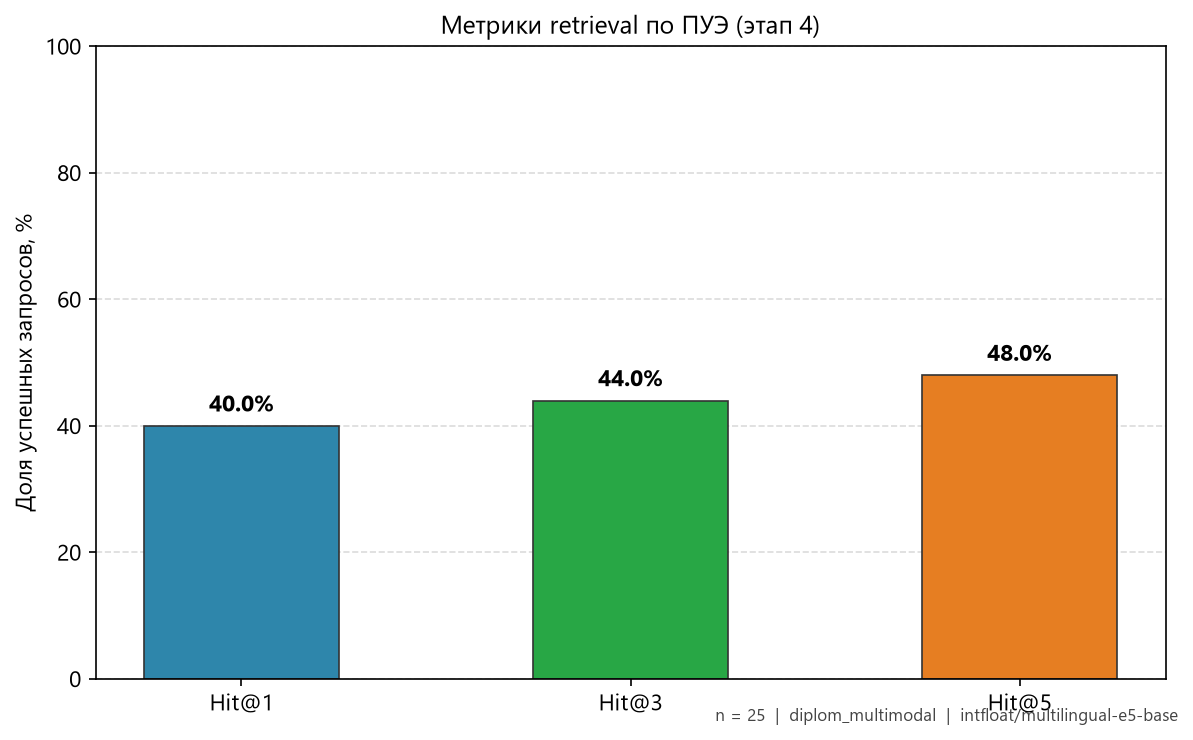

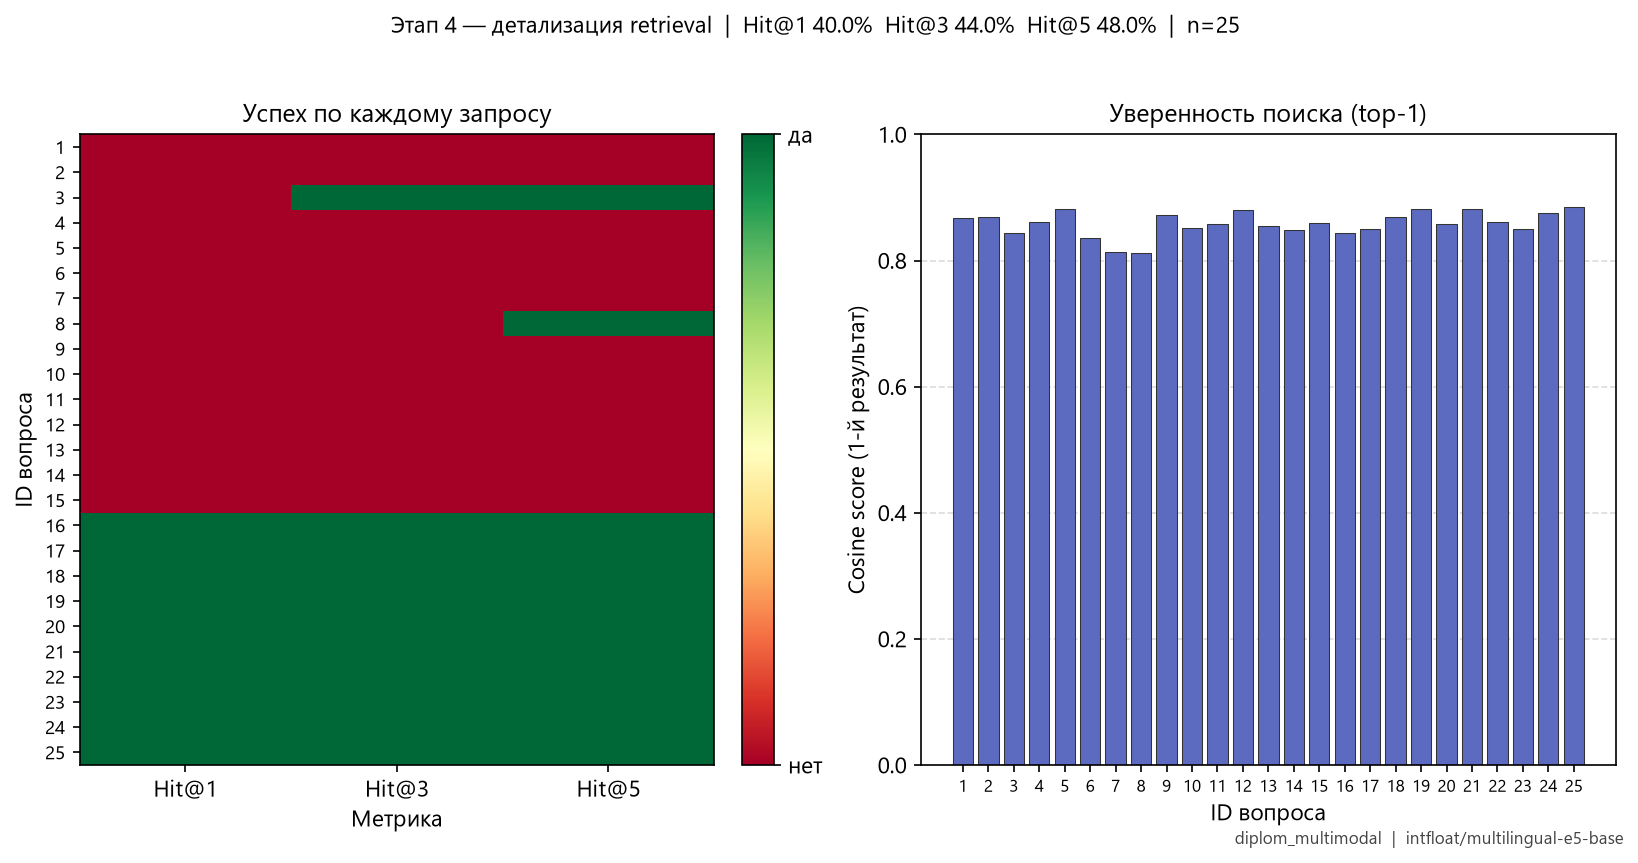

In [9]:
# §5.3: таблица, Plotly, PNG — актуальные данные после §5.2
import importlib
import importlib.util
import sys

force_eval = False  # True — новый прогон Milvus перед отображением

_scripts = ROOT / "scripts"
if str(_scripts) not in sys.path:
    sys.path.insert(0, str(_scripts))

_nb_name = "stage4_hitk_notebook"
if _nb_name in sys.modules:
    _nb = importlib.reload(sys.modules[_nb_name])
else:
    _spec = importlib.util.spec_from_file_location(
        _nb_name, _scripts / "stage4_eval" / "stage4_hitk_notebook.py"
    )
    _nb = importlib.util.module_from_spec(_spec)
    sys.modules[_nb_name] = _nb
    assert _spec.loader is not None
    _spec.loader.exec_module(_nb)

from report_paths import STAGE4_HITK_RESULTS
results_path = STAGE4_HITK_RESULTS
results = _nb.ensure_results(
    REPORTS, ROOT, results_path, refresh_readme=False, force_eval=force_eval
)
_nb.render_section_53(results, REPORTS, ROOT, results_path=results_path)


Полный JSON и графики: `etap4/retrieval/` (см. таблицу в начале документа). При изменении `etap4/data/stage4_eval_questions.json` снова запустите §5.2 — обновятся §5.3, §6.1 и *N* в §4.4 / §7.

### 6.3. Метрики generation (дополнение к Hit@k)

Скрипт `scripts/stage4_eval/eval_rag_generation.py` (режим `live` — Milvus + Ollama; `mock` — офлайн по chunked). Результаты: `etap4/generation/stage4_gen_eval_results.json`, пояснение: `etap4/generation/Etap4-gen-metrics.md`.

```powershell
python scripts/stage4_eval/eval_rag_generation.py --mode live
```


<a id="sec-6"></a>
## 6. Ноутбук или .py файл (прототип)

**Два артефакта этапа 4:**

| Файл | Роль |
|------|------|
| **`etap4/Readme-4.md`** (этот документ) | Мастер-текст для **Word**: разделы 1–8 и приложения |
| **`etap4/Readme-4 (ver. 2).ipynb`** | **Рабочий** отчёт: те же разделы 1–8 + исполняемые ячейки (Hit@k, демо Milvus) |

После правок текста в `.md` обновите markdown-ячейки ноутбука: `python scripts/sync_readme4_notebook.py`.

**Python-скрипты** (логика прототипа, можно запускать без ноутбука):

| Файл | Назначение |
|------|------------|
| `scripts/stage4_eval/demo_stage4_milvus_search.py` | Демо семантического поиска (§6 ноутбука) |
| `scripts/test_rag_ollama.py` | Полный RAG (Milvus + Ollama) |
| `scripts/sync_readme4_notebook.py` | Обновить текст ячеек ноутбука из `Readme-4.md` |
| `scripts/notebook_bootstrap.py` | Корень проекта и `sys.path` (первая ячейка ноутбука) |
| `scripts/start_report_docker.py` | Milvus + Ollama через Docker (вторая code-ячейка ноутбука) |
| `scripts/stage4_eval/demo_stage4_milvus_search.py` | Демо `search_text` к Milvus (ячейка §6 ноутбука) |
| `src/preprocessing/Create_embeddings/query_test.py` | То же из терминала |
| `scripts/stage4_eval/eval_retrieval_hitk.py` | Прототип оценки «первой точности» (Hit@k) |
| `scripts/stage4_eval/update_readme4_eval_docs.py` | Обновление §5.3 / §6.1 в `Readme-4.md` из JSON (в конце eval) |
| `scripts/stage4_eval/eval_rag_generation.py` | Метрики generation / citation / groundedness (live или mock) |
| `scripts/stage4_eval/stage4_hitk_notebook.py` | §5.2 / §5.3 ноутбука (прогон и графики) |
| `scripts/stage4_eval/stage4_hitk_report.py` | Текст §5.3 / §6.1 / §7 из JSON |
| `scripts/stage4_eval/plot_stage4_hitk.py` | PNG и Plotly для Hit@k |
| `scripts/report_paths.py` | Единые пути к артефактам в `etap4/` |
| `scripts/stage4_eval/README.md` | Мануал прогона метрик |
| `etap4/data/stage4_eval_questions.json` | 25 тестовых вопросов и эталонные пункты ПУЭ |

### 6.1. Тестовый набор (эталоны)

<!-- stage4-eval:6.1:start -->
| № | Вопрос (кратко) | Эталон Clause |
|---|-----------------|---------------|
| 1 | На какое максимальное напряжение распространяются прави... | 1.1.1 |
| 2 | Дай определение электроустановки по ПУЭ | 1.1.3 |
| 3 | Чем отличаются открытые и закрытые электроустановки? | 1.1.4 |
| 4 | Учитывает ли ПУЭ планово-предупредительные испытания и ... | 1.1.2 |
| 5 | Определение сырых помещений по относительной влажности | 1.1.8 |
| 6 | Кто такой квалифицированный обслуживающий персонал элек... | 1.1.14 |
| 7 | Определение заземления и зануления | 1.7.1 |
| 8 | Что такое система TN в электроустановках? | 1.7.2 |
| 9 | Система IT — определение | 1.7.3 |
| 10 | Нулевой защитный проводник и нулевой рабочий проводник | 1.7.103 |
| 11 | Защитное отключение | 1.7.83 |
| 12 | Что означает глухозаземленная нейтраль? | 1.7.5 |
| 13 | Какие испытания должно пройти новое электрооборудование... | 1.8.1 |
| 14 | Дай определение электропроводки | 2.1.2 |
| 15 | Что такое лоток в электропроводке? | 2.1.11 |
| 16 | На какие кабельные линии распространяется глава 2.3 ПУЭ? | 2.3.1 |
| 17 | Что называется аппаратом защиты в главах про защиту сетей? | 3.1.2 |
| 18 | Селективность защиты и защита от токов короткого замыка... | 3.1.8 |
| 19 | Какие сети внутри помещений должны быть защищены от пер... | 3.1.10 |
| 20 | На какие установки распространяется глава 3.2 о релейно... | 3.2.1 |
| 21 | На что распространяется глава 4.1 про распределительные... | 4.1.1 |
| 22 | На какие электромашинные помещения распространяется гла... | 5.1.1 |
| 23 | На какие установки электрического освещения распростран... | 6.1.1 |
| 24 | На электроустановки каких зданий распространяется глава... | 7.1.1 |
| 25 | На какие электроустановки распространяется глава 7.3 о ... | 7.3.1 |
| 26 | Что такое электропомещения по ПУЭ? | 1.1.5 |
| 27 | Какие помещения считаются сухими по относительной влажн... | 1.1.6 |
| 28 | Определение влажных помещений по ПУЭ | 1.1.7 |
| 29 | Что такое особо сырые помещения? | 1.1.9 |
| 30 | Система TT — определение | 1.7.4 |
| 31 | Заземляющее устройство электроустановки | 1.7.55 |
| 32 | Определение токоведущей части электроустановки | 1.7.8 |
| 33 | Определение открытой проводящей части | 1.7.9 |
| 34 | Что такое сторонняя проводящая часть по ПУЭ? | 1.7.10 |
| 35 | Основная система уравнивания потенциалов | 1.7.76 |
| 36 | Дополнительная система уравнивания потенциалов | 1.7.77 |
| 37 | Защита от поражения электрическим током в электроустано... | 1.7.80 |
| 38 | Безопасное напряжение по ПУЭ | 1.7.82 |
| 39 | Какое устройство называется приемником электрической эн... | 1.2.7 |
| 40 | Какое сечение должен иметь заземляющий проводник, присо... | 1.7.117 |
| 41 | Каким должно быть минимальное сечение медных защитных п... | 1.7.127 |
| 42 | Каким образом обозначаются проводники защитного заземле... | 1.1.29 |
| 43 | Какое определение соответствует термину "защитное зазем... | 1.7.29 |
| 44 | Какое сечение должен иметь заземляющий проводник, присо... | 1.7.117 |
| 45 | Каким должно быть напряжение холостого хода источника с... | 7.6.57 |
| 46 | Какое оборудование называется потребителем электрическо... | 1.2.8 |
| 47 | Что может быть применено для защиты при косвенном прико... | 1.7.62 |
| 48 | Каким должно быть минимальное сечение медных проводнико... | 1.7.137 |
| 49 | Какое определение соответствует термину "глухозаземленн... | 1.7.5 |
| 50 | Какое напряжение должно применяться для питания перенос... | 6.1.17 |
| 51 | Каким должно быть минимальное сечение алюминиевых прово... | 1.7.137 |
| 52 | Какое определение соответствует термину "защита от прям... | 1.7.13 |
| 53 | Каким должно быть минимальное сечение стальных проводни... | 1.7.137 |
| 54 | Каким образом классифицируются помещения в отношении оп... | 1.1.13 |
| 55 | Какое определение соответствует термину "защита при кос... | 1.7.14 |
| 56 | Какое оборудование должно использоваться при присоедине... | 7.6.24 |
| 57 | На каком расстоянии от сварочного поста должен располаг... | 7.6.19 |
| 58 | Какие помещения называются сырыми, согласно Правилам ус... | 1.1.8 |
| 59 | Какое определение соответствует термину "заземлитель", ... | 1.7.15 |
| 60 | Какой максимально допустимой длины должен быть гибкий к... | 7.6.25 |
| 61 | В каком случае допускается располагать сварочные посты ... | 7.6.35 |
| 62 | Какие помещения относятся к влажным, согласно Правилам ... | 1.1.7 |
| 63 | Какое определение соответствует термину "искусственный ... | 1.7.16 |
| 64 | При каком напряжении шкафы комплектных устройств и корп... | 7.6.27 |
| 65 | Какие требования предъявляются к отдельному помещению д... | 7.6.37 |
| 66 | Какие помещения называются сухими, согласно Правилам ус... | 1.1.6 |
| 67 | Какое определение соответствует термину "естественный з... | 1.7.17 |
| 68 | Какое сопротивление должно иметь в любое время года заз... | 1.7.101 |
| 69 | Каким должно быть напряжение холостого хода источника с... | 7.6.57 |
| 70 | Каким образом должны быть обозначены нулевые рабочие (н... | 1.1.29 |
| 71 | Какое определение соответствует термину "заземление", с... | 1.7.28 |
| 72 | Какие дополнительные мероприятия при сооружении искусст... | 1.7.107 |
| 73 | Каким должно быть напряжение холостого хода источника с... | 7.6.57 |
<!-- stage4-eval:6.1:end -->

*(Полные формулировки — в `stage4_eval_questions.json`.)*

### 6.2. Пример прототипа generation (промпт для Ollama)

```
Ты — помощник по ПУЭ. Отвечай только на основе приведённых фрагментов.
Если ответа нет в контексте — так и скажи.
Указывай номера пунктов ПУЭ.

Контекст:
{фрагменты из search_text}

Вопрос: {query}

Ответ:
```

Вызов API: `POST http://localhost:11434/api/generate` с полями `model`, `prompt`, `stream: false`.

---


In [ ]:
from report_paths import STAGE4_QUESTIONS as questions_path
if questions_path.is_file():
    qs = json.loads(questions_path.read_text(encoding="utf-8"))
    print(f"Тестовых вопросов: {len(qs)}")
    for row in qs[:5]:
        q = row["query"][:65] + ("…" if len(row["query"]) > 65 else "")
        print(f"  [{row['id']}] {row['expected_clause']} — {q}")
else:
    print("Файл stage4_eval_questions.json не найден")

Тестовых вопросов: 25
  [1] 1.1.1 — На какое максимальное напряжение распространяются правила устройс…
  [2] 1.1.3 — Дай определение электроустановки по ПУЭ
  [3] 1.1.4 — Чем отличаются открытые и закрытые электроустановки?
  [4] 1.7.1 — Определение заземления и зануления
  [5] 1.7.103 — Нулевой защитный проводник и нулевой рабочий проводник


In [ ]:
# Демо search_text → Milvus (скрипт; нужны bootstrap, Docker, Milvus с данными)
import subprocess
import sys

_script = ROOT / "scripts" / "stage4_eval" / "demo_stage4_milvus_search.py"
if not _script.is_file():
    raise FileNotFoundError(_script)

_rc = subprocess.run(
    [sys.executable, str(_script)], cwd=str(ROOT), check=False
)
if _rc.returncode != 0:
    raise RuntimeError(
        f"demo_stage4_milvus_search: код {_rc.returncode}. "
        "Смотрите вывод выше (Milvus, load_data, модель). "
        "Нужны bootstrap и Docker-ячейка §5.1."
    )
print(
    "\nℹ️ Демо §6 успешно: итоговая сводка — в блоке «Итог демо search_text» в выводе выше."
)

<a id="sec-7"></a>
## 7. Выводы

В ноутбуке: **code-ячейка §7** ниже — пункты с актуальными Hit@k из `stage4_hitk_results.json` (после §5.2).


In [ ]:
# §7: выводы с актуальными Hit@k из JSON (после §5.2)
import importlib
import importlib.util
import sys
from IPython.display import Markdown, display

from report_paths import STAGE4_HITK_RESULTS
results_path = STAGE4_HITK_RESULTS
_scripts = ROOT / "scripts"
if str(_scripts) not in sys.path:
    sys.path.insert(0, str(_scripts))

_report_name = "stage4_hitk_report"
if _report_name in sys.modules:
    report_mod = importlib.reload(sys.modules[_report_name])
else:
    spec = importlib.util.spec_from_file_location(
        _report_name, _scripts / "stage4_eval" / "stage4_hitk_report.py"
    )
    report_mod = importlib.util.module_from_spec(spec)
    sys.modules[_report_name] = report_mod
    assert spec.loader is not None
    spec.loader.exec_module(report_mod)

if not results_path.is_file():
    print("Нет stage4_hitk_results.json — сначала ячейка §5.2 (прогон Hit@k).")
else:
    results = json.loads(results_path.read_text(encoding="utf-8"))
    print(f"§7 — данные прогона: {results.get('evaluated_at', '—')}")
    display(Markdown(report_mod.build_section_7_markdown(results)))


§7 — данные прогона: 29.09.2026 02:43


1. **База ПУЭ** подготовлена и проиндексирована; **прототип рабочего контура RAG** опирается на чанки с метаданными пунктов.
2. **Retrieval** — **SentenceTransformer + Milvus** (`search_text`) — реализован; конфиг `rag_runtime.json`.
3. **Первая измеримая точность** — **Hit@k** (25 вопросов, один поиск на вопрос); скрипт `eval_retrieval_hitk.py` и график. На прогоне **29.09.2026 02:43**: Hit@1 **40.0%**, Hit@3 **44.0%**, Hit@5 **48.0%** (`eval_retrieval_hitk.py`, `Этапы/Reports/stage4_hitk_results.json`).
4. **Generation** — **Ollama** в `src/rag/rag_service.py`; Telegram-бот — этап 5.
5. Ограничения: промахи retrieval; LLM — только при опоре на top-k контекст.

<a id="sec-8"></a>
## 8. План дальнейшей работы (этап 5 и защита)

| Приоритет | Задача |
|-----------|--------|
| 1 | Подключить RAG к Telegram-боту (`src/bot/__main__.py`) |
| 2 | Довести Hit@k и качество ответов LLM на тестовом наборе |
| 3 | Docker Compose: бот + Milvus + Ollama в одной сети |
| 4 | **Этап 5:** финальная версия системы + повторная оценка метрик |
| 5 | **Этап 6:** презентация и demo-сценарий для интервью |
| 6 | Опционально: SQLite-история, ПТЭЭП, reranker |

---

## Приложения

- Конфиг: `config/rag_runtime.json`
- Инструкция запуска: `start/Readme.md`
- Отчёт этап 3: `Этапы/Reports/etap3/Readme-3 (ver. 4).ipynb`
- Исполняемый отчёт: `Этапы/Reports/etap4/Readme-4 (ver. 2).ipynb` (этот ноутбук)
- Текст для Word: `Этапы/Reports/etap4/Readme-4.md`
- Оглавление каталога Reports: `Этапы/Reports/README.md`
- Теория Hit@k и каталог книг (в Git — только `*.md`): `manual/README.md`, `manual/Hit_at_k.md`

### Источники по метрике Hit@k (п. 4.4)

1. Manning C. D., Raghavan P., Schütze H. *Introduction to Information Retrieval*. Cambridge University Press, 2008. Глава 8. Evaluation in information retrieval. — Precision@k, Recall@k для ранжированной выдачи. Онлайн: https://nlp.stanford.edu/IR-book/
2. Karpukhin V. et al. *Dense Passage Retrieval for Open-Domain Question Answering* // Proceedings of EMNLP. 2020. — top-k retrieval accuracy (доля вопросов, у которых ответ есть в top-k пассажах).
3. Lewis P. et al. *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* // NeurIPS. 2020. — постановка RAG: качество ответа зависит от retrieval.

*График для сдачи: `Этапы/Reports/etap4/retrieval/stage4_hitk_chart.png` или вывод ячейки раздела 5.*
